<a href="https://colab.research.google.com/github/albertbolanoss/labs_deep_learning/blob/main/notebooks/handwritten-digits/03_deep_nn_handwritten_digit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Tensoflow

## Load dependencies

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from matplotlib import pyplot as plt

## Load data

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:

print(f"X train shape: {X_train.shape}")
print(f"Y train shape: {y_train.shape}")
print(f"X test shape: {X_test.shape}")
print(f"Y test shape: {y_test.shape}")

X train shape: (60000, 28, 28)
Y train shape: (60000,)
X test shape: (10000, 28, 28)
Y test shape: (10000,)


## Visualize data

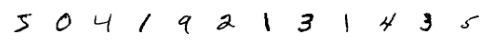

In [4]:
plt.figure(figsize=(5,5))
for k in range(12):
    plt.subplot(1,12,k+1)
    plt.imshow(X_train[k], cmap="Greys")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [5]:
y_train[0:12]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5], dtype=uint8)

In [ ]:
X_test[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  84, 185, 159, 151,  60,  36,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 222, 254, 254, 254, 254, 241, 198,
        198, 198, 198, 198, 198, 198, 198, 170,  52,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  67, 114,  72, 114, 163, 227, 254,
        225, 254, 254, 254, 250, 229, 254, 254, 140,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  17,  66,
         14,  67,  67,  67,  59,  21, 236, 254, 106,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,  83, 253, 209,  18,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,  22, 233, 255,  83,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 129, 254, 238,  44,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  59, 249, 254,  62,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0, 133, 254, 187,   5,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   9, 205, 248,  58,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 126, 254, 182,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  75, 251, 240,  57,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         19, 221, 254, 166,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
        203, 254, 219,  35,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  38,
        254, 254,  77,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 224,
        254, 115,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 133, 254,
        254,  52,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

## Utilities to save, load the model and checkpoints

In [6]:
import os
import io
from google.colab import auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload
import tensorflow as tf
from tensorflow.keras.models import load_model


def get_drive_service():
    """Autentica al usuario y retorna el servicio de Google Drive."""
    auth.authenticate_user()
    return build('drive', 'v3')

def save_model_to_drive(model_obj: tf.keras.Model, filename: str, folder_id: str, drive_service) -> str:
    """Guarda un modelo de Keras localmente y lo sube a Google Drive."""
    local_path = f"/content/{filename}"
    model_obj.save(local_path)
    print(f"Modelo guardado localmente en {local_path}")

    file_metadata = {'name': filename, 'parents': [folder_id]}
    media = MediaFileUpload(local_path, mimetype='application/octet-stream')

    print("Subiendo a Google Drive...")
    file = drive_service.files().create(
        body=file_metadata,
        media_body=media,
        fields='id'
    ).execute()

    file_id = file.get('id')
    print(f"Modelo subido con ID: {file_id}")
    return file_id

def load_model_from_drive(filename: str, folder_id: str, drive_service, custom_objects: dict = None):
    """Descarga un modelo desde Google Drive y lo carga en Keras."""
    print(f"Buscando '{filename}' en Drive...")

    query = f"name = '{filename}' and '{folder_id}' in parents and trashed = false"
    results = drive_service.files().list(q=query, fields="files(id)").execute()
    items = results.get('files', [])

    if not items:
        raise FileNotFoundError(f"No se encontró '{filename}' en la carpeta {folder_id}.")

    file_id = items[0]['id']
    local_path = f"/content/downloaded_{filename}"

    # Descarga
    request = drive_service.files().get_media(fileId=file_id)
    with io.FileIO(local_path, 'wb') as fh:
        downloader = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            status, done = downloader.next_chunk()
            if status:
                print(f"Descarga {int(status.progress() * 100)}%.", end='\r')

    print("\nDescarga completa. Cargando modelo...")

    # Carga en memoria
    return load_model(local_path, custom_objects=custom_objects)

class DriveModelCheckpoint(Callback):
    """Guarda el modelo en Drive solo si la métrica monitoreada mejora."""
    def __init__(self, drive_service, folder_id: str, filename: str = 'best_model.keras', monitor: str = 'val_loss', verbose: int = 1):
        super().__init__()
        self.drive_service = drive_service
        self.folder_id = folder_id
        self.filename = filename
        self.monitor = monitor
        self.verbose = verbose
        self.best = float('inf')
        self.file_id = self._get_existing_file_id()

    def _get_existing_file_id(self):
        query = f"name = '{self.filename}' and '{self.folder_id}' in parents and trashed = false"
        results = self.drive_service.files().list(q=query, fields="files(id)").execute()
        items = results.get('files', [])
        return items[0]['id'] if items else None

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return

        if current < self.best:
            if self.verbose > 0:
                print(f"\nÉpoca {epoch+1}: {self.monitor} mejoró de {self.best:.4f} a {current:.4f}. Actualizando Drive...")
            self.best = current
            self._save_and_overwrite()

    def _save_and_overwrite(self):
        local_path = f"/content/{self.filename}"
        self.model.save(local_path)

        media = MediaFileUpload(local_path, mimetype='application/octet-stream')
        try:
            if self.file_id:
                self.drive_service.files().update(fileId=self.file_id, media_body=media).execute()
            else:
                file_metadata = {'name': self.filename, 'parents': [self.folder_id]}
                file = self.drive_service.files().create(body=file_metadata, media_body=media, fields='id').execute()
                self.file_id = file.get('id')
        except Exception as e:
            print(f"Error subiendo a Drive: {e}")


## Pre procesing

In [7]:
X_train = X_train.reshape(60000, 784).astype("float32")
X_test = X_test.reshape(10000, 784).astype("float32")

X_train /=255
X_test  /=255

X_train[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [8]:
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

y_train[0]


array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

## Design Neuron Network Architecture

In [ ]:
model = Sequential()

# Hidden layers
            # neurons / Activation  / input size / weights initializer / bias initializer  
            # glorot_uniform is the default value
model.add(Dense(64, activation="relu", input_shape=(784,), kernel_initializer="glorot_uniform", bias_initializer="zeros"))
model.add(BatchNormalization())  # Normalize the outputs to avoid Neuron Saturation

model.add(Dense(64, activation="relu"))
model.add(BatchNormalization())  # Normalize the outputs to avoid Neuron Saturation

# output layer
model.add(Dense(10, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

### Calculate the Neuronal Network Parameters

In [10]:
input_size = 28 * 28
layer_1_size = 64
layer_1_bias = layer_1_size # each neuron of the layer 1 has one bias
layer_2_size = 64
layer_2_bias = layer_2_size # each neuron of the layer 2 has one bias
layer_3_size = 10
layer_3_bias = layer_3_size # each neuron of the layer 3 has one bias

layer_1_total_parameter = (input_size * layer_1_size) + layer_1_bias
layer_2_total_parameter = (layer_2_size * layer_1_size) + layer_2_bias
layer_3_total_parameter = (layer_3_size * layer_2_size) + layer_3_bias
total_parameters = layer_1_total_parameter + layer_2_total_parameter + layer_3_total_parameter

print(f"Layer 1 Parameters: {layer_1_total_parameter}")
print(f"Layer 2 Parameters: {layer_2_total_parameter}")
print(f"Total parameters: {total_parameters}")

Layer 1 Parameters: 50240
Layer 2 Parameters: 4160
Total parameters: 55050


##  Theory

1. Primera Capa (dense_1): De Píxeles a Formas Básicas
En esta capa (donde tenemos los más de 50 mil pesos), las neuronas todavía no saben nada sobre las categorías 0, 1, 2, etc. En lugar de predecir el número final, los pesos de estos 64 "analistas" interpretan qué tan importante es cada píxel para detectar patrones geométricos o trazos.

Ejemplo: Durante el entrenamiento, la neurona oculta #1 podría especializarse en detectar "un círculo en la parte superior derecha". Los pesos que conectan los píxeles de esa esquina específica hacia la neurona #1 serán muy altos y positivos, mientras que los píxeles de las esquinas inferiores tendrán pesos cercanos a cero.

Otra neurona, la #15, podría especializarse en detectar "una línea vertical recta en el centro".

2. Segunda Capa (dense_2): De Formas Básicas a Categorías
Aquí es donde entran las categorías (los 10 "jefes" que representan los números del 0 al 9).

En esta etapa ya no miramos píxeles. Los 640 pesos de esta capa interpretan qué tan importante es cada patrón (descubierto por las 64 neuronas) para decidir el número final.

Ejemplo: Si la neurona oculta #1 (la que detecta un círculo arriba) está muy activa, el peso que la conecta con la categoría "8" o "9" será altísimo (porque esos números tienen un círculo arriba).

Por el contrario, el peso que conecta a esa misma neurona con la categoría "1" o "4" será fuertemente negativo, porque si hay un círculo arriba, la red deduce que casi seguro no es un uno ni un cuatro.

## La Arquitectura de tu Código Keras

Tu modelo define el siguiente flujo de información:

Entrada (Input): Un vector de 784 números crudos (por ejemplo, los píxeles individuales de una imagen en blanco y negro).

Capa Oculta (Dense 64): 64 neuronas. Cada una recibe los 784 números, los multiplica por sus propios pesos, suma un sesgo (bias) y pasa el resultado por la función Sigmoide, comprimiendo el valor entre 0 y 1.

Capa de Salida (Dense 10): 10 neuronas. Reciben los 64 resultados "aplastados" de la capa anterior, aplican nuevos pesos y sesgos, y pasan por Softmax para darte 10 probabilidades (ej. detectando dígitos del 0 al 9).

## Compile model

1. loss="mean_squared_error" (La Función de Pérdida)
Qué indica: Es la brújula del modelo. Le dice a la red cómo calcular qué tan equivocada está en sus predicciones actuales comparadas con las respuestas reales.

Qué estamos haciendo: Estamos usando el Error Cuadrático Medio. El modelo toma su predicción, la resta del valor real (la etiqueta correcta del número), y eleva el resultado al cuadrado. Entre más grande sea el número final, mayor fue el error.

Nota arquitectónica para tu proyecto: Aunque matemáticamente el modelo compilará, mean_squared_error se usa típicamente para problemas de regresión (predecir valores continuos, como precios o distancias). Dado que estás clasificando categorías distintas (dígitos del 0 al 9) usando una activación softmax en tu última capa, la convención y mejor práctica en Deep Learning es usar loss="categorical_crossentropy" (o sparse_categorical_crossentropy). Esta función está diseñada matemáticamente para lidiar con las probabilidades que entrega el softmax.

2. optimizer=SGD(lrn=0.01) (El Optimizador)
Qué indica: Es el algoritmo (el "mecánico") encargado de actualizar las más de 50 mil "perillas" (pesos y sesgos) que calculamos anteriormente, basándose en el error que descubrió la función de pérdida.

Qué estamos haciendo: SGD significa Stochastic Gradient Descent (Descenso de Gradiente Estocástico). Le estás diciendo al modelo que, tras evaluar qué tan mal le fue, ajuste los pesos matemáticamente para "descender" hacia el punto donde el error es mínimo.

El parámetro de tasa de aprendizaje: El valor 0.01 define el tamaño del "paso" que da el optimizador al ajustar los pesos.

Si el paso es muy grande, la red altera los pesos violentamente, volviéndose inestable.

Si el paso es muy pequeño, aprenderá bien pero el entrenamiento tomará muchísimo tiempo computacional. 0.01 es un excelente punto de equilibrio para empezar.

Detalle de código: En las versiones modernas de Keras/TensorFlow, el parámetro de la tasa de aprendizaje se debe declarar como learning_rate=0.01 en lugar de lrn.

3. metrics=['accurracy'] (La Métrica)
Qué indica: Es el indicador de rendimiento humano. Mientras que el loss es un número abstracto que la máquina usa para aprender internamente, la métrica es un valor fácil de interpretar para ti como desarrollador.

Qué estamos haciendo: Le estamos pidiendo a Keras que, durante cada ronda de entrenamiento, nos muestre el porcentaje de acierto (Accuracy). Si te muestra 0.92, significa que la red clasificó correctamente el 92% de las imágenes de números escritos a mano.

**log loss = –y ln(ŷ) – (1 – y) ln(1 – ŷ)**

Se conoce como Binary Cross-Entropy (Entropía Cruzada Binaria) o Log Loss estándar. Esta fórmula está diseñada matemáticamente para problemas donde solo hay dos opciones (ej. ¿Es un perro o un gato? ¿Es spam o no es spam? 0 o 1).



**Fórmula de Categorical Cross-Entropy:**

Loss = - [ y_0 * ln(ŷ_0)  +  y_1 * ln(ŷ_1)  + ... +  y_9 * ln(ŷ_9) ]

Donde:
y = Valor real (1 si es la clase correcta, 0 si son las incorrectas)
ŷ = Probabilidad que predijo el modelo para esa clase

In [11]:
model.compile(loss="categorical_crossentropy", optimizer=SGD(learning_rate=0.01), metrics=['accuracy'])


## Callbacks

In [13]:
# 1. Early Stopping: Detiene el entrenamiento si el val_loss no mejora en 10 épocas seguidas
early_stopper = EarlyStopping(
    monitor='val_loss',
    patience=10,             # Cuántas épocas esperar sin mejora antes de detener
    restore_best_weights=True, # Restaura los pesos de la mejor época (¡Súper importante!)
    verbose=1
)


# 2. Local checkpoint
local_checkpoint = ModelCheckpoint(
    filepath='/content/digits.keras',
    monitor='val_loss',
    save_best_only=True
)

# 2. OneDriver checkpoint
# drive_checkpoint = DriveModelCheckpoint(
#     drive_service=drive_service,
#     folder_id=GOOGLE_DRIVE_FOLDER_ID,
#     filename=MODEL_TO_SAVE,
#     monitor='val_loss'
# )


## Train

In [14]:
model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    verbose=True,
    validation_data=(X_test, y_test),
    callbacks=[early_stopper, local_checkpoint]
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6329 - loss: 1.4203 - val_accuracy: 0.8337 - val_loss: 0.7049
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8566 - loss: 0.5604 - val_accuracy: 0.8816 - val_loss: 0.4466
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8842 - loss: 0.4209 - val_accuracy: 0.8974 - val_loss: 0.3717
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8961 - loss: 0.3678 - val_accuracy: 0.9046 - val_loss: 0.3352
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9043 - loss: 0.3375 - val_accuracy: 0.9114 - val_loss: 0.3148
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9100 - loss: 0.3164 - val_accuracy: 0.9148 - val_loss: 0.2972
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9151 - loss: 0.2998 - val_accuracy: 0.9192 - val_loss: 0.2868
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9189 - loss: 0.2866 - val_accuracy: 0.

## Get DriveOne Service

In [15]:
GOOGLE_DRIVE_FOLDER_ID = "14LvaZfifLwoGsnIbwINaEZMSLEpP4E4-"
MODEL_TO_SAVE = "digits.keras"

drive_service = get_drive_service()

### Saving Model

In [16]:
save_model_to_drive(
    model_obj=model,
    filename=MODEL_TO_SAVE,
    folder_id=GOOGLE_DRIVE_FOLDER_ID,
    drive_service=drive_service
)
print("Model saved and uploaded successfully.")

Modelo guardado localmente en /content/digits.keras
Subiendo a Google Drive...
Modelo subido con ID: 1pUe3stltFxhfwuON-lyNYNo52OAA0ZdL
Model saved and uploaded successfully.


## Load model

In [17]:
loaded_model = load_model_from_drive(
    filename=MODEL_TO_SAVE,
    folder_id=GOOGLE_DRIVE_FOLDER_ID,
    drive_service=drive_service
)

# Verificar
if loaded_model:
    loaded_model.summary()

Buscando 'digits.keras' en Drive...
Descarga 100%.
Descarga completa. Cargando modelo...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,052 (215.05 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Evaluate Model

In [18]:
loaded_model.evaluate(X_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9625 - loss: 0.1224


[0.12243019789457321, 0.9624999761581421]

## Inference

In [19]:
import numpy as np

data = X_test[0].reshape(1, 784)


# 1. Generar las probabilidades (devuelve 10 valores por cada imagen/dato)
probabilidades = loaded_model.predict(data)

# 2. Extraer el índice de la probabilidad más alta (la clase predicha, de 0 a 9)
clases_predichas = np.argmax(probabilidades, axis=-1)

# Ver los resultados
print(clases_predichas)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[7]


## Checking data

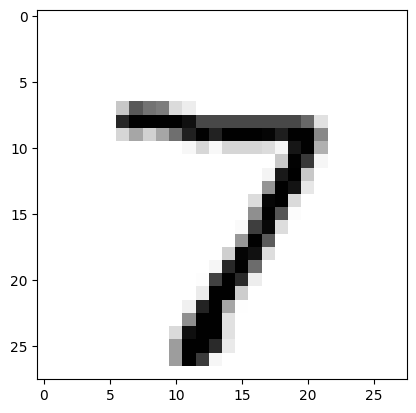

In [20]:
plt.imshow(X_test[0].reshape(28, 28), cmap="Greys")
